## MLPI26 Lecture 6 Supplement 1

# Model Evaluation, Model Selection and Hyperparameter Tuning

### A worked case study: predicting robot grasp failures on a bin-picking cell

---

A production cell uses a 2-finger parallel gripper to pick parts out of a bin. Most picks work.
A few do not: the part slips, tips out of the fingers, or is never lifted at all. A failed pick
costs a re-plan, a cycle, sometimes a damaged part.

We have **1400 logged pick attempts**. For each one the cell recorded what it knew *before*
the pick (part properties from the vision system, the grasp the planner chose, the state of the
gripper) and what happened *after* (success or failure). The question is:

> Can we predict, before committing to a pick, that this grasp is going to fail —
> so that the planner can choose a different one?

That is a supervised binary classification problem. But building a classifier is the easy part.
This notebook is about the harder part: **knowing how good it actually is, and choosing between
the many models you could have built.**

### What you will be able to do afterwards

1. Explain why a single train/test split gives an unreliable performance number, and use
   **k-fold cross-validation** instead (and why *stratified* folds matter for rare events).
2. Read a **learning curve** and a **validation curve** and say whether the model is
   underfitting, overfitting, or starved of data.
3. Tune hyperparameters with **`GridSearchCV`** and **`RandomizedSearchCV`**, and say when
   each is the better use of your compute budget.
4. Choose evaluation metrics that survive **class imbalance** — **precision**, **recall**,
   **F1** — instead of accuracy.
5. Read a **ROC curve** and a **precision–recall curve**, and interpret **AUC**.
6. Assemble all of it into an evaluation protocol that does not lie to you.

**Prerequisites:** basic Python, NumPy/pandas, and having fitted at least one scikit-learn model.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)

# plot style used throughout
plt.rcParams.update({
    "figure.figsize": (9, 3.6), "figure.dpi": 110,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "font.size": 10, "legend.frameon": False,
})
BLUE, ORANGE, AQUA, YELLOW, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#898781"

RANDOM_STATE = 42

python       3.11.15
numpy        2.4.4
pandas       3.0.2
scikit-learn 1.8.0


---
## 1. The data

The dataset below is **synthetic but physically motivated**, so the whole notebook is
reproducible on any machine with no download. The generative model encodes real gripper
physics: a grasp is likely to fail when the commanded grip force cannot overcome the weight
through friction, when the grasp point is far from the part's centroid (a moment about the
fingertips), when the approach is tilted, and when the part is far from the width the
fingertips are shaped for.

| feature | meaning | source |
|---|---|---|
| `object_mass_g` | part mass | part database / vision |
| `object_width_mm` | grasp width across the part | vision |
| `surface_friction` | estimated friction coefficient | material lookup |
| `approach_angle_deg` | tilt of the gripper axis vs. the ideal approach | planner |
| `grasp_offset_mm` | distance of the grasp point from the centroid | planner |
| `grip_force_N` | commanded closing force | controller |
| `bin_clutter` | number of parts touching this one | vision |
| `ft_variance` | force/torque variance while the jaws close | gripper sensor |
| `gripper_temp_C` | finger temperature | gripper sensor |
| `cycle_count_k` | thousands of cycles on the current finger pads | maintenance log |

**Target:** `grasp_failed` — `1` if the pick failed. The positive class is the *rare, expensive*
event. That convention matters: precision and recall are always computed with respect to the
positive class, and here "positive" means "this grasp is going to go wrong".

In [2]:
G = 9.81
NOMINAL_WIDTH_MM = 58.0     # width the fingertips are shaped for


def make_grasp_dataset(n=1400, seed=7):
    '''Return (X, y) for n logged pick attempts. y = 1 means the grasp FAILED.'''
    rng = np.random.default_rng(seed)

    # --- part and scene properties -----------------------------------------
    object_mass_g = np.clip(rng.lognormal(4.6, 0.55, n), 20, 600)
    object_width_mm = np.clip(rng.normal(56, 13, n), 22, 86)
    surface_friction = np.clip(rng.beta(2.6, 2.6, n) * 0.8 + 0.12, 0.12, 0.92)
    bin_clutter = rng.integers(0, 8, n)

    # --- how well the planner placed the gripper ---------------------------
    approach_angle_deg = np.clip(np.abs(rng.normal(0, 8.5, n)) + 0.35 * bin_clutter, 0, 38)
    grasp_offset_mm = np.clip(rng.gamma(2.0, 2.4, n) + 0.30 * bin_clutter, 0, 22)

    # --- gripper command and state -----------------------------------------
    grip_force_N = np.clip(rng.normal(26, 6.5, n), 6, 45)
    gripper_temp_C = np.clip(rng.normal(31, 4.5, n), 20, 48)
    cycle_count_k = np.clip(rng.gamma(2.2, 22.0, n), 0, 260)
    wear = cycle_count_k / 260.0                       # pads wear -> friction drops
    eff_friction = surface_friction * (1.0 - 0.22 * wear)

    ft_variance = np.clip(0.35 + 0.09 * bin_clutter + 0.05 * grasp_offset_mm
                          + 0.02 * approach_angle_deg + rng.normal(0, 0.28, n), 0.05, None)

    # --- physics-flavoured risk drivers ------------------------------------
    required_N = (object_mass_g / 1000) * G / (2 * eff_friction + 1e-6)   # to hold the weight
    force_margin = (grip_force_N - required_N) / 10.0                     # > 0 is comfortable
    moment = (object_mass_g / 1000) * G * (grasp_offset_mm / 1000) * 60.0
    angle_n = approach_angle_deg / 12.0
    offset_n = grasp_offset_mm / 8.0
    width_mismatch = ((object_width_mm - NOMINAL_WIDTH_MM) / 18.0) ** 2    # quadratic!

    logit = (-1.95
             - 1.70 * force_margin
             + 1.05 * moment
             + 0.95 * angle_n
             + 1.70 * width_mismatch
             + 0.30 * bin_clutter / 3.0
             + 0.45 * wear
             + 1.70 * angle_n * offset_n      # interaction: tilted AND off-centre
             + 0.35 * ft_variance)
    y = rng.binomial(1, 1 / (1 + np.exp(-logit)))

    X = pd.DataFrame({
        "object_mass_g": object_mass_g, "object_width_mm": object_width_mm,
        "surface_friction": surface_friction, "approach_angle_deg": approach_angle_deg,
        "grasp_offset_mm": grasp_offset_mm, "grip_force_N": grip_force_N,
        "bin_clutter": bin_clutter.astype(float), "ft_variance": ft_variance,
        "gripper_temp_C": gripper_temp_C, "cycle_count_k": cycle_count_k,
    }).round(3)
    return X, pd.Series(y, name="grasp_failed")


X, y = make_grasp_dataset()
print(f"{len(X)} logged picks, {X.shape[1]} features")
print(f"failures: {y.sum()}  ({y.mean():.1%})   successes: {(1-y).sum()}  ({1-y.mean():.1%})")
X.head()

1400 logged picks, 10 features
failures: 252  (18.0%)   successes: 1148  (82.0%)


,object_mass_g,object_width_mm,surface_friction,approach_angle_deg,grasp_offset_mm,grip_force_N,bin_clutter,ft_variance,gripper_temp_C,cycle_count_k
0,99.552,40.368,0.731,16.853,4.542,20.716,0.0,0.626,28.227,34.078
1,117.250,53.695,0.729,2.757,6.920,24.708,2.0,0.825,34.770,65.800
2,85.561,27.364,0.896,2.372,4.786,27.807,4.0,1.111,32.737,43.954
3,60.957,33.874,0.313,14.041,4.650,32.718,5.0,0.965,30.993,32.404
4,77.473,57.195,0.562,1.048,2.730,27.444,0.0,0.656,25.588,36.913


### 1.1 The first thing to notice: the classes are imbalanced

Only about **18 %** of picks fail. Write that number down, because it is the trap:

> A model that predicts "success" for every single pick is **82 % accurate**.

Eighty-two percent sounds respectable in a report and is completely worthless on the cell —
it never flags anything, so it never prevents a single failed pick. Accuracy on imbalanced
problems measures the class balance, not the model. We will come back to this in §7.

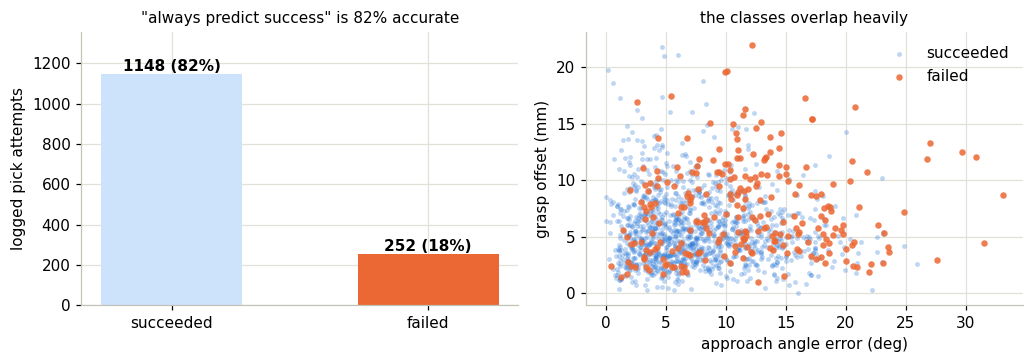

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))

counts = y.value_counts().sort_index()
ax[0].bar(["succeeded", "failed"], counts, color=["#cde2fb", ORANGE], width=0.55)
for i, c in enumerate(counts):
    ax[0].text(i, c + 15, f"{c} ({c/len(y):.0%})", ha="center", fontweight="bold")
ax[0].set_ylim(0, counts.max() * 1.18)
ax[0].set_ylabel("logged pick attempts")
ax[0].set_title(f'"always predict success" is {1-y.mean():.0%} accurate', fontsize=10)

m = y == 1
ax[1].scatter(X.loc[~m, "approach_angle_deg"], X.loc[~m, "grasp_offset_mm"],
              s=10, c=BLUE, alpha=0.30, lw=0, label="succeeded")
ax[1].scatter(X.loc[m, "approach_angle_deg"], X.loc[m, "grasp_offset_mm"],
              s=18, c=ORANGE, alpha=0.85, lw=0, label="failed")
ax[1].set_xlabel("approach angle error (deg)")
ax[1].set_ylabel("grasp offset (mm)")
ax[1].set_title("the classes overlap heavily", fontsize=10)
ax[1].legend()
plt.tight_layout()
plt.show()

### 1.2 Hold out a test set *before* anything else

Split once, right now, and then **do not touch the test set again** until the very last cell
of this notebook. Everything in between — every plot, every hyperparameter, every model
comparison — is decided using cross-validation *inside the training set*.

`stratify=y` keeps the 18 % failure rate identical in both halves. Without it, a random split
can easily hand you a test set with a noticeably different failure rate, and your test score
then measures the split as much as the model.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"train: {len(X_train):4d} picks, failure rate {y_train.mean():.3f}")
print(f"test:  {len(X_test):4d} picks, failure rate {y_test.mean():.3f}   <- locked away")

train: 1050 picks, failure rate 0.180
test:   350 picks, failure rate 0.180   <- locked away


---
## 2. Why one train/test split is not enough

A single split gives you **one number**. How much would that number have changed if the random
split had gone differently? Let's just measure it: fit the same model on 60 different random
75/25 splits of the same data, and look at the spread of test scores.

(We score with ROC AUC here; §8 explains what it means. For now treat it as "a number between
0.5 and 1.0, higher is better".)

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def svm_pipeline(C=1.0, gamma="scale"):
    '''Scaling + RBF SVM as ONE estimator. §3.2 explains why this must be a Pipeline.'''
    return Pipeline([("scaler", StandardScaler()),
                     ("svc", SVC(kernel="rbf", C=C, gamma=gamma))])


scores_one_split = []
for seed in range(60):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)
    model = svm_pipeline(C=10, gamma=0.01).fit(Xa, ya)
    scores_one_split.append(roc_auc_score(yb, model.decision_function(Xb)))

scores_one_split = np.array(scores_one_split)
print(f"worst split : {scores_one_split.min():.3f}")
print(f"best  split : {scores_one_split.max():.3f}")
print(f"spread      : {np.ptp(scores_one_split):.3f} AUC   <- same model, same data!")

worst split : 0.799
best  split : 0.922
spread      : 0.123 AUC   <- same model, same data!


That spread is the point. Two engineers can run the *identical* model on the *identical* data,
pick different random seeds, and disagree by more than the difference between a good model and a
mediocre one. Any comparison based on a single split is partly measuring luck.

The cure is to **average over several splits**, which is exactly what k-fold cross-validation does.

---
## 3. k-fold cross-validation

Split the training data into $k$ equal blocks ("folds"). Then run $k$ rounds: in round $i$,
train on all blocks except block $i$ and validate on block $i$. Every sample is used for
validation exactly once, and for training $k-1$ times.

```
round 1   [VALID][train][train][train][train]
round 2   [train][VALID][train][train][train]
round 3   [train][train][VALID][train][train]
round 4   [train][train][train][VALID][train]
round 5   [train][train][train][train][VALID]
                                        ->  score = mean of the 5 validation scores
```

**Choosing $k$.** $k=5$ and $k=10$ are the usual choices. Larger $k$ means more training data
per round (less pessimistic bias) but $k$ times the compute; $k = n$ is leave-one-out, which is
expensive and has high variance. For a few thousand samples, **$k=5$ is a good default** and it
is what we use throughout.

**Stratification.** With a rare positive class, plain `KFold` lets the failure rate drift from
fold to fold, which adds noise you did not ask for. `StratifiedKFold` forces every fold to have
(almost exactly) the overall class proportion. **For classification, always stratify.**

In [6]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, cross_validate

plain = KFold(n_splits=5, shuffle=True, random_state=1)
strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

rows = []
for name, splitter in [("KFold", plain), ("StratifiedKFold", strat)]:
    rates = [y.iloc[te].mean() for _, te in splitter.split(X, y)]
    rows.append([name] + [f"{r:.3f}" for r in rates] + [f"{max(rates)-min(rates):.3f}"])

print(f"overall failure rate: {y.mean():.3f}\n")
print(pd.DataFrame(rows, columns=["splitter", "f1", "f2", "f3", "f4", "f5", "spread"])
        .to_string(index=False))

overall failure rate: 0.180

       splitter    f1    f2    f3    f4    f5 spread
          KFold 0.186 0.168 0.179 0.186 0.182  0.018
StratifiedKFold 0.182 0.182 0.179 0.179 0.179  0.004


### 3.1 `cross_val_score` in practice

`cross_val_score` does the whole loop for you: clone the estimator, fit, score, repeat.
Report **mean ± standard deviation** — the standard deviation across folds tells you how much
to trust the mean, and it is what stops you from over-reading a 0.005 difference between two
models.

In [7]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fold_scores = cross_val_score(svm_pipeline(C=10, gamma=0.01), X_train, y_train,
                              cv=cv5, scoring="roc_auc")

print("fold scores:", np.round(fold_scores, 3))
print(f"5-fold estimate: {fold_scores.mean():.3f} +/- {fold_scores.std():.3f}")

fold scores: [0.85  0.872 0.837 0.905 0.857]
5-fold estimate: 0.864 +/- 0.023


In [8]:
# cross_validate gives several metrics in one pass, plus timings
res = cross_validate(svm_pipeline(C=10, gamma=0.01), X_train, y_train, cv=cv5,
                     scoring=["roc_auc", "average_precision", "precision", "recall", "f1"],
                     return_train_score=True)

summary = pd.DataFrame({
    "metric": ["roc_auc", "average_precision", "precision", "recall", "f1"],
    "train":  [res[f"train_{m}"].mean() for m in
               ["roc_auc", "average_precision", "precision", "recall", "f1"]],
    "validation": [res[f"test_{m}"].mean() for m in
                   ["roc_auc", "average_precision", "precision", "recall", "f1"]],
    "val. std": [res[f"test_{m}"].std() for m in
                 ["roc_auc", "average_precision", "precision", "recall", "f1"]],
}).round(3)
summary

,metric,train,validation,val. std
0,roc_auc,0.900,0.864,0.023
1,average_precision,0.752,0.649,0.032
2,precision,0.887,0.770,0.091
3,recall,0.317,0.270,0.074
4,f1,0.467,0.395,0.096


### 3.2 The mistake that quietly inflates every score: preprocessing outside the loop

`StandardScaler` learns a mean and a standard deviation **from data**. If you scale the whole
training set once and *then* cross-validate, each fold's validation block has already
contributed to the scaler — information has leaked from validation into training, and your
score comes out optimistic.

The fix is mechanical: put every fitted step inside a `Pipeline`. Then `cross_val_score` refits
the scaler on each fold's training part only. This is why `svm_pipeline()` above returns a
`Pipeline` and not a bare `SVC`.

```python
# WRONG - the scaler saw the validation folds
X_scaled = StandardScaler().fit_transform(X_train)
cross_val_score(SVC(), X_scaled, y_train, cv=cv5)

# RIGHT - the scaler is refitted inside every fold
cross_val_score(Pipeline([("scaler", StandardScaler()), ("svc", SVC())]),
                X_train, y_train, cv=cv5)
```

The same rule covers feature selection, imputation, PCA, resampling — anything that *learns*
from the data. Rule of thumb: **if it has a `.fit()` method, it belongs inside the pipeline.**

---
## 4. Learning curves: is the model limited by data or by itself?

A **learning curve** plots training and validation score against the *number of training
examples*. It answers a question you cannot answer from a single score: *would collecting more
logged picks help?*

| what you see | diagnosis | what to do |
|---|---|---|
| both curves low, close together, flat | **underfitting** (high bias) | more expressive model, better features |
| training high, validation much lower, gap persists | **overfitting** (high variance) | more data, regularise, reduce capacity |
| curves converging, still rising | still data-limited | collect more data |

Below: the same data, two models. On the left a linear model (logistic regression) — it cannot
represent the quadratic width effect or the angle×offset interaction, so both curves settle
low and together. On the right an RBF SVM with `gamma` far too large — it memorises the
training set (training AUC = 1.0) and generalises worse than the linear model.

underfitting: linear model             final train 0.808  val 0.797


overfitting: RBF SVM, gamma = 3.0      final train 1.000  val 0.697


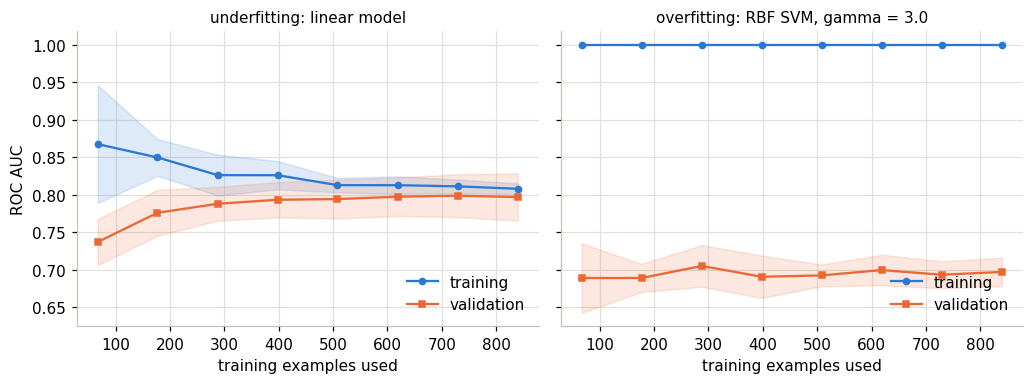

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve

models = {
    "underfitting: linear model":
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
    "overfitting: RBF SVM, gamma = 3.0":
        svm_pipeline(C=100, gamma=3.0),
}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
for ax, (title, model) in zip(axes, models.items()):
    sizes, train_sc, val_sc = learning_curve(
        model, X_train, y_train, train_sizes=np.linspace(0.08, 1.0, 8),
        cv=cv5, scoring="roc_auc", n_jobs=-1, shuffle=True, random_state=0)
    ax.plot(sizes, train_sc.mean(1), "o-", color=BLUE, ms=4, label="training")
    ax.fill_between(sizes, train_sc.mean(1)-train_sc.std(1),
                    train_sc.mean(1)+train_sc.std(1), color=BLUE, alpha=0.15)
    ax.plot(sizes, val_sc.mean(1), "s-", color=ORANGE, ms=4, label="validation")
    ax.fill_between(sizes, val_sc.mean(1)-val_sc.std(1),
                    val_sc.mean(1)+val_sc.std(1), color=ORANGE, alpha=0.15)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("training examples used")
    ax.legend(loc="lower right")
    print(f"{title:38s} final train {train_sc.mean(1)[-1]:.3f}  val {val_sc.mean(1)[-1]:.3f}")
axes[0].set_ylabel("ROC AUC")
plt.tight_layout()
plt.show()

Read the two panels as *different prescriptions*:

- **Left (underfit).** The gap is already closed and the curve is flat. Logging another 5000
  picks would change nothing. You need a model that can bend, or engineered features
  (e.g. the physical quantities `required_force / grip_force` and `mass × offset`).
- **Right (overfit).** A huge, persistent gap. More data *would* help — and so would simply
  turning `gamma` down, which costs nothing. That is what §5 does.

---
## 5. Validation curves: one hyperparameter at a time

A **validation curve** plots training and validation score against **one hyperparameter**, with
everything else fixed. It is the diagnostic tool that tells you *which way* to move a knob and
*where the useful range is* — which is how you choose sensible bounds for the searches in §6.

For an RBF SVM there are two knobs:

- **$\gamma$** — the reach of one training point in the kernel
  $k(\mathbf{x},\mathbf{x}') = \exp(-\gamma\lVert \mathbf{x}-\mathbf{x}'\rVert^2)$.
  Small $\gamma$ = wide, smooth influence = nearly linear (underfit). Large $\gamma$ = each
  point only influences its immediate neighbourhood = the model memorises (overfit).
- **$C$** — how expensive a margin violation is. Small $C$ = a soft, heavily regularised
  boundary. Large $C$ = the model tries hard to classify every training point correctly.

Both are searched on a **logarithmic** scale, because what matters is the order of magnitude.

best gamma = 0.01874   validation AUC = 0.862
best     C = 23.1   validation AUC = 0.864


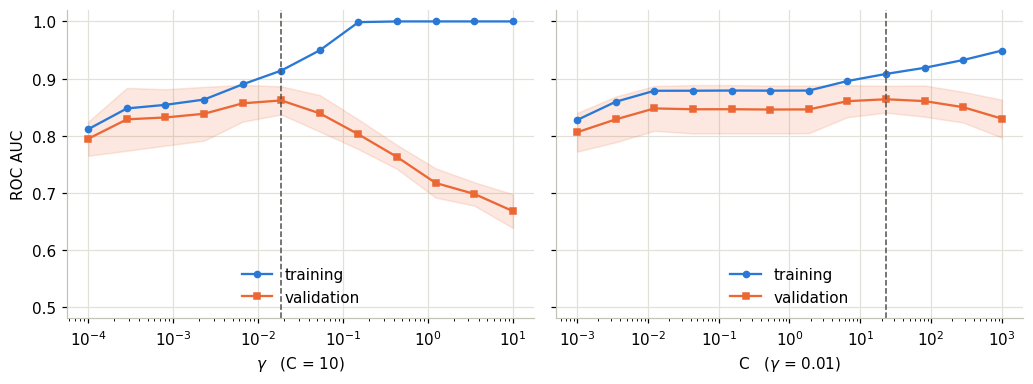

In [10]:
from sklearn.model_selection import validation_curve

gammas = np.logspace(-4, 1, 12)
train_g, val_g = validation_curve(svm_pipeline(C=10), X_train, y_train,
                                  param_name="svc__gamma", param_range=gammas,
                                  cv=cv5, scoring="roc_auc", n_jobs=-1)

Cs = np.logspace(-3, 3, 12)
train_c, val_c = validation_curve(svm_pipeline(gamma=0.01), X_train, y_train,
                                  param_name="svc__C", param_range=Cs,
                                  cv=cv5, scoring="roc_auc", n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
labels = ["gamma", "C"]
for ax, name, (rng_, tr, va, lab) in zip(axes, labels,
        [(gammas, train_g, val_g, r"$\gamma$   (C = 10)"),
         (Cs, train_c, val_c, r"C   ($\gamma$ = 0.01)")]):
    ax.semilogx(rng_, tr.mean(1), "o-", color=BLUE, ms=4, label="training")
    ax.semilogx(rng_, va.mean(1), "s-", color=ORANGE, ms=4, label="validation")
    ax.fill_between(rng_, va.mean(1)-va.std(1), va.mean(1)+va.std(1), color=ORANGE, alpha=0.15)
    best = rng_[np.argmax(va.mean(1))]
    ax.axvline(best, color="#52514e", ls="--", lw=1)
    ax.set_xlabel(lab)
    ax.legend(loc="lower center")
    print(f"best {name:>5s} = {best:.4g}   validation AUC = {va.mean(1).max():.3f}")
axes[0].set_ylabel("ROC AUC")
axes[0].set_ylim(0.48, 1.02)
plt.tight_layout()
plt.show()

The left panel is the classic bias–variance picture in one plot. As $\gamma$ grows the training
curve climbs to a perfect 1.0 while the validation curve peaks and then collapses: the model is
fitting noise. The best $\gamma$ sits at the peak of the **validation** curve — never the
training curve.

**Warning.** A validation curve varies one knob with the others frozen. Because $C$ and
$\gamma$ interact, the single-knob optimum is not necessarily the joint optimum. Use validation
curves to find the *interesting range*, then search the parameters *jointly* — which is §6.

---
## 6. Grid search: try every combination

`GridSearchCV` takes a dictionary of parameter values, evaluates **every combination** with
cross-validation, and refits the best one on the whole training set.

Cost is the thing to keep in mind: `n_combinations × k` model fits. Our grid of
4 values of $C$ × 5 values of $\gamma$ = 20 combinations × 5 folds = **100 fits**. Add a third
parameter with 5 values and it is 500. Grid search is exhaustive, reproducible, and grows
exponentially in the number of parameters — that is the whole trade-off.

Note the `svc__C` naming: `<step name>__<parameter name>` addresses a parameter inside a
pipeline step.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {"svc__C":     [0.1, 1, 10, 100],
              "svc__gamma": [0.001, 0.003, 0.01, 0.03, 0.1]}

grid = GridSearchCV(svm_pipeline(), param_grid, scoring="roc_auc",
                    cv=cv5, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print(f"combinations : {len(grid.cv_results_['params'])}")
print(f"model fits   : {len(grid.cv_results_['params']) * cv5.get_n_splits()}")
print(f"best params  : {grid.best_params_}")
print(f"best CV AUC  : {grid.best_score_:.4f}")

combinations : 20
model fits   : 100
best params  : {'svc__C': 100, 'svc__gamma': 0.003}
best CV AUC  : 0.8647


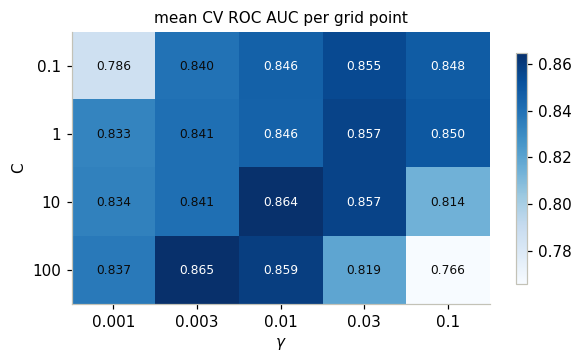

In [12]:
# the score surface: a heat map is the fastest way to see whether your grid was well placed
scores = grid.cv_results_["mean_test_score"].reshape(len(param_grid["svc__C"]),
                                                     len(param_grid["svc__gamma"]))
fig, ax = plt.subplots(figsize=(5.6, 3.4))
im = ax.imshow(scores, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(param_grid["svc__gamma"])), param_grid["svc__gamma"])
ax.set_yticks(range(len(param_grid["svc__C"])), param_grid["svc__C"])
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel("C")
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(j, i, f"{scores[i, j]:.3f}", ha="center", va="center", fontsize=8,
                color="white" if scores[i, j] > scores.max() - 0.02 else "#0b0b0b")
ax.grid(False)
ax.set_title("mean CV ROC AUC per grid point", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

Two habits worth forming when you read that heat map:

1. **Check whether the best point is on the edge of the grid.** If it is, the grid was placed
   badly — extend it in that direction and search again.
2. **Check how flat the surface is.** If a dozen cells are within one fold-standard-deviation of
   the best, "the best" is largely noise. Prefer the simplest (most regularised) setting in that
   plateau rather than the literal argmax.

---
## 7. Random search: sample instead of enumerate

`RandomizedSearchCV` draws `n_iter` random combinations from *distributions* you specify, so
**you set the compute budget directly** instead of inheriting it from the size of the grid.

Why it works so well in practice: in most problems only one or two hyperparameters really
matter, but you do not know which in advance. A grid with 4 levels per parameter only ever
tries **4 distinct values** of the important one, no matter how many points it evaluates —
every other evaluation is a repeat of the same value with different settings of parameters
that do not matter. Twenty random draws try **20 distinct values** of every parameter.

Use `loguniform` for scale parameters like $C$ and $\gamma$ so that the samples are spread
evenly across orders of magnitude.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {"svc__C": loguniform(1e-1, 1e3),
              "svc__gamma": loguniform(1e-4, 1e0)}

rand = RandomizedSearchCV(svm_pipeline(), param_dist, n_iter=20, scoring="roc_auc",
                          cv=cv5, n_jobs=-1, random_state=0, refit=True)
rand.fit(X_train, y_train)

print(f"model fits  : {20 * cv5.get_n_splits()}   (same budget as the grid)")
print(f"best params : C = {rand.best_params_['svc__C']:.3f}, "
      f"gamma = {rand.best_params_['svc__gamma']:.4f}")
print(f"best CV AUC : {rand.best_score_:.4f}")
print(f"\ngrid   best CV AUC : {grid.best_score_:.4f}")
print(f"random best CV AUC : {rand.best_score_:.4f}")

model fits  : 100   (same budget as the grid)
best params : C = 6.677, gamma = 0.0188
best CV AUC : 0.8650

grid   best CV AUC : 0.8647
random best CV AUC : 0.8650


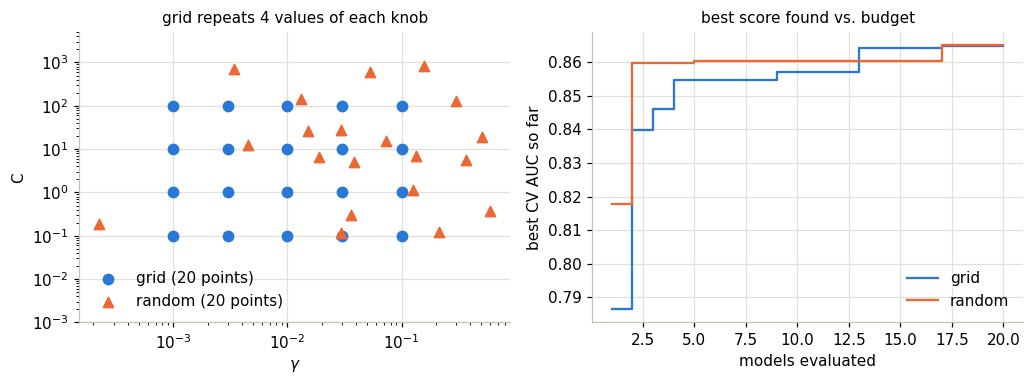

In [14]:
# where the two searches spend their 20 evaluations
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))

gC = [p["svc__C"] for p in grid.cv_results_["params"]]
gG = [p["svc__gamma"] for p in grid.cv_results_["params"]]
rC = [p["svc__C"] for p in rand.cv_results_["params"]]
rG = [p["svc__gamma"] for p in rand.cv_results_["params"]]
ax[0].scatter(gG, gC, s=45, c=BLUE, label="grid (20 points)")
ax[0].scatter(rG, rC, s=45, c=ORANGE, marker="^", label="random (20 points)")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_ylim(1e-3, 5e3)
ax[0].set_xlabel(r"$\gamma$"); ax[0].set_ylabel("C"); ax[0].legend(loc="lower left")
ax[0].set_title("grid repeats 4 values of each knob", fontsize=10)

ax[1].step(range(1, 21), np.maximum.accumulate(grid.cv_results_["mean_test_score"]),
           where="post", color=BLUE, label="grid")
ax[1].step(range(1, 21), np.maximum.accumulate(rand.cv_results_["mean_test_score"]),
           where="post", color=ORANGE, label="random")
ax[1].set_xlabel("models evaluated"); ax[1].set_ylabel("best CV AUC so far")
ax[1].legend(loc="lower right")
ax[1].set_title("best score found vs. budget", fontsize=10)
plt.tight_layout()
plt.show()

**Which one should you use?**

| | grid search | random search |
|---|---|---|
| budget | fixed by the grid: $\prod_i n_i$ | you choose `n_iter` |
| coverage per parameter | $n_i$ distinct values | `n_iter` distinct values |
| continuous parameters | must be discretised by hand | sampled from a distribution |
| ≤ 2–3 parameters, known good ranges | **good choice** | fine |
| ≥ 4 parameters, or ranges unknown | scales badly | **good choice** |
| reproducible & exhaustive | yes | only via `random_state` |

A practical recipe: **random search wide first** to find the promising region, then a **small
grid search** inside it to polish. And whichever you use, take the winning score with a pinch of
salt — see §10.

---
## 8. Precision and recall: metrics that survive imbalance

Now the metrics. Fix a model (the winner from §6/§7) and look at *what kind* of mistakes it makes.
Every binary prediction falls into one of four boxes:

|  | predicted success | predicted failure |
|---|---|---|
| **actually succeeded** | TN — correct, pick proceeds | **FP** — false alarm, a needless re-plan |
| **actually failed** | **FN** — missed failure, the part is dropped | TP — caught, the planner re-plans |

$$
\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad
F_1 = 2\,\frac{\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}
$$

In the language of the cell:

- **Precision** — of the grasps we flagged as risky, how many really would have failed.
  Low precision means we are crying wolf and throwing away good cycles.
- **Recall** — of the grasps that really would have failed, how many did we catch.
  Low recall means dropped parts still get through.
- **F1** — their harmonic mean, a single number when you need one. It punishes a model that
  wins on one metric by sacrificing the other.

Note what all three have in common: **none of them counts TN**. That is exactly why they do not
get inflated by 1148 easy successes, and accuracy does.

In [15]:
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)

best_model = grid.best_estimator_ if grid.best_score_ >= rand.best_score_ else rand.best_estimator_
best_model.fit(X_train, y_train)

# cross-validated predictions on the TRAINING set - the test set stays closed until §10
from sklearn.model_selection import cross_val_predict
y_cv_pred = cross_val_predict(best_model, X_train, y_train, cv=cv5)

cm = confusion_matrix(y_train, y_cv_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN {tn:4d}   FP {fp:4d}\nFN {fn:4d}   TP {tp:4d}\n")
print(f"accuracy  {accuracy_score(y_train, y_cv_pred):.3f}   <- looks great, means little")
print(f"precision {precision_score(y_train, y_cv_pred):.3f}   = {tp}/({tp}+{fp})")
print(f"recall    {recall_score(y_train, y_cv_pred):.3f}   = {tp}/({tp}+{fn})")
print(f"F1        {f1_score(y_train, y_cv_pred):.3f}\n")
print(classification_report(y_train, y_cv_pred, target_names=["succeeded", "failed"]))

TN  837   FP   24
FN  123   TP   66

accuracy  0.860   <- looks great, means little
precision 0.733   = 66/(66+24)
recall    0.349   = 66/(66+123)
F1        0.473

              precision    recall  f1-score   support

   succeeded       0.87      0.97      0.92       861
      failed       0.73      0.35      0.47       189

    accuracy                           0.86      1050
   macro avg       0.80      0.66      0.70      1050
weighted avg       0.85      0.86      0.84      1050



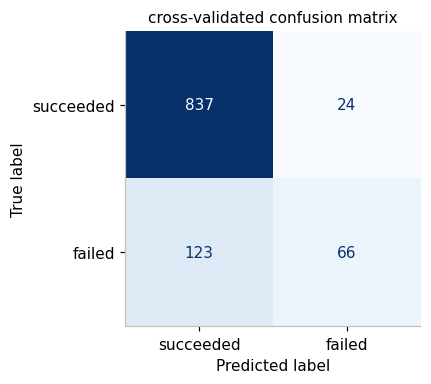

In [16]:
fig, ax = plt.subplots(figsize=(4.4, 3.6))
ConfusionMatrixDisplay(cm, display_labels=["succeeded", "failed"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("cross-validated confusion matrix", fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

### 8.1 The threshold is a design decision, not a constant

`predict()` uses a fixed cut-off (score > 0 for an SVM, probability > 0.5 for most other
classifiers). Nothing forces you to keep it. Sliding the threshold trades precision against
recall along a curve, and where you sit on that curve should follow from the cost of each
mistake — on this cell, a dropped part (FN) is worth many needless re-plans (FP), so you would
deliberately move the threshold to buy recall.

The **precision–recall curve** shows every operating point at once. `average_precision_score`
(AP) summarises it in one number. The flat reference line is the no-skill baseline: a random
classifier achieves precision = the positive rate, **0.18** here, not 0.5 — so an AP of about 0.65
is roughly 3.6x better than chance.

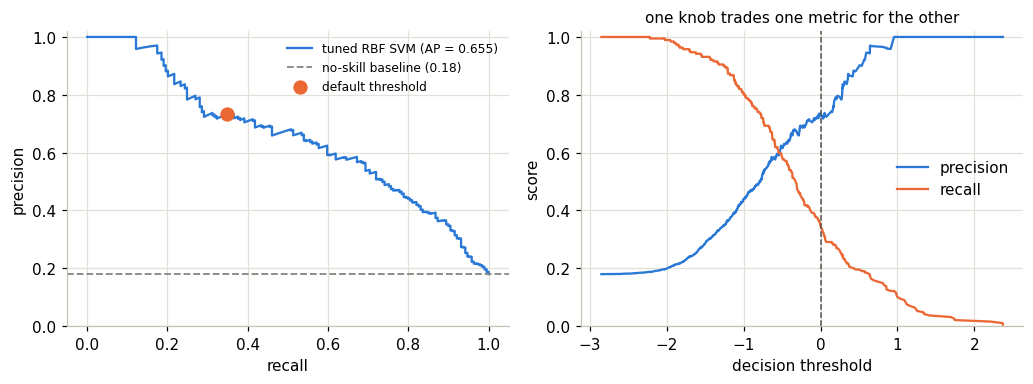

to reach recall 0.70 you move the threshold to -0.732 and precision falls to 0.54


In [17]:
from sklearn.metrics import (PrecisionRecallDisplay, average_precision_score,
                             precision_recall_curve)

# cross-validated scores, so this plot still does not touch the test set
y_cv_score = cross_val_predict(best_model, X_train, y_train, cv=cv5, method="decision_function")
prec, rec, thr = precision_recall_curve(y_train, y_cv_score)
ap = average_precision_score(y_train, y_cv_score)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].plot(rec, prec, color=BLUE, label=f"tuned RBF SVM (AP = {ap:.3f})")
ax[0].axhline(y_train.mean(), color=MUTED, ls="--", lw=1.2,
              label=f"no-skill baseline ({y_train.mean():.2f})")
ax[0].scatter([recall_score(y_train, y_cv_pred)], [precision_score(y_train, y_cv_pred)],
              s=70, color=ORANGE, zorder=5, label="default threshold")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].set_ylim(0, 1.02)
ax[0].legend(loc="upper right", fontsize=8)

ax[1].plot(thr, prec[:-1], color=BLUE, label="precision")
ax[1].plot(thr, rec[:-1], color=ORANGE, label="recall")
ax[1].axvline(0, color="#52514e", ls="--", lw=1)
ax[1].set_xlabel("decision threshold"); ax[1].set_ylabel("score"); ax[1].set_ylim(0, 1.02)
ax[1].legend(loc="center right")
ax[1].set_title("one knob trades one metric for the other", fontsize=10)
plt.tight_layout()
plt.show()

# what would it cost to catch 70% of the failures?
target = 0.70
i = np.argmin(np.abs(rec[:-1] - target))
print(f"to reach recall {rec[i]:.2f} you move the threshold to {thr[i]:+.3f} "
      f"and precision falls to {prec[i]:.2f}")

---
## 9. ROC curves and AUC

The **ROC curve** is the other view of the same sweep. As the threshold moves from "flag
everything" to "flag nothing" it plots

$$
\text{TPR} = \text{recall} = \frac{TP}{TP+FN}
\qquad\text{against}\qquad
\text{FPR} = \frac{FP}{FP+TN}
$$

- Bottom-left = flag nothing. Top-right = flag everything. The diagonal = random guessing.
- The perfect classifier reaches the top-left corner: all failures caught, no false alarms.
- **AUC** is the area under that curve. It has a clean interpretation:
  **AUC is the probability that a randomly chosen failing grasp is scored higher than a randomly
  chosen succeeding one.** 0.5 = coin flip, 1.0 = perfect ranking.

AUC is *threshold-free* — it measures how well the model **ranks**, not how well one particular
cut-off classifies. That is why it is a good model-selection metric (we used it as `scoring=`
throughout) and a poor deployment metric: the cell has to pick a threshold eventually.

**ROC vs. PR under imbalance.** The FPR denominator is the large negative class, so hundreds of
false alarms move the ROC curve only slightly — ROC can look flattering when positives are rare.
The PR curve divides by the positives, so it stays honest. Report **both**: ROC AUC for
comparing models, average precision for judging usefulness at the operating point.

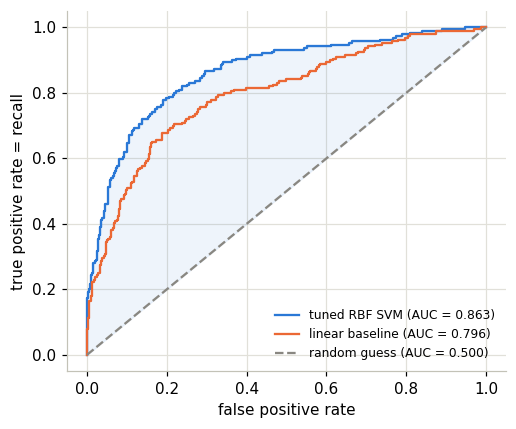

In [18]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score, roc_curve

baseline = Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000))])
y_cv_score_base = cross_val_predict(baseline, X_train, y_train, cv=cv5,
                                    method="decision_function")

fpr_t, tpr_t, _ = roc_curve(y_train, y_cv_score)
fpr_b, tpr_b, _ = roc_curve(y_train, y_cv_score_base)

fig, ax = plt.subplots(figsize=(4.8, 4.0))
ax.plot(fpr_t, tpr_t, color=BLUE,
        label=f"tuned RBF SVM (AUC = {roc_auc_score(y_train, y_cv_score):.3f})")
ax.plot(fpr_b, tpr_b, color=ORANGE,
        label=f"linear baseline (AUC = {roc_auc_score(y_train, y_cv_score_base):.3f})")
ax.plot([0, 1], [0, 1], ls="--", color=MUTED, label="random guess (AUC = 0.500)")
ax.fill_between(fpr_t, tpr_t, fpr_t, color=BLUE, alpha=0.08)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate = recall")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### 9.1 Side by side: what each metric says about the same three models

Including the do-nothing model that always predicts "success".

In [19]:
from sklearn.dummy import DummyClassifier

def evaluate(name, estimator, Xd, yd):
    pred = cross_val_predict(estimator, Xd, yd, cv=cv5)
    try:
        score = cross_val_predict(estimator, Xd, yd, cv=cv5, method="decision_function")
    except AttributeError:
        score = cross_val_predict(estimator, Xd, yd, cv=cv5, method="predict_proba")[:, 1]
    return {
        "model": name,
        "accuracy":  accuracy_score(yd, pred),
        "precision": precision_score(yd, pred, zero_division=0),
        "recall":    recall_score(yd, pred),
        "F1":        f1_score(yd, pred),
        "ROC AUC":   roc_auc_score(yd, score),
        "avg prec":  average_precision_score(yd, score),
    }

table = pd.DataFrame([
    evaluate("always 'success'", DummyClassifier(strategy="most_frequent"), X_train, y_train),
    evaluate("linear baseline", baseline, X_train, y_train),
    evaluate("tuned RBF SVM", best_model, X_train, y_train),
]).round(3)
table

,model,accuracy,precision,recall,F1,ROC AUC,avg prec
0,always 'success',0.820,0.000,0.000,0.000,0.500,0.180
1,linear baseline,0.841,0.638,0.270,0.379,0.796,0.542
2,tuned RBF SVM,0.860,0.733,0.349,0.473,0.863,0.655


Look at the first row. The do-nothing model scores **0.82 accuracy** — higher than you might
have guessed — and **0.00** on precision, recall and F1, with an AUC of exactly 0.5. Every
metric except accuracy correctly reports that this model is worthless. That single row is the
argument for never reporting accuracy alone on an imbalanced problem.

---
## 10. The final evaluation — open the test set once

Everything so far used only `X_train`. The model was selected, tuned, diagnosed and inspected
without the test set ever being read. Now, and only now, we score it — **once**.

Why the discipline matters: with 20 candidate models compared on the same CV folds, the winner
is partly the model that got lucky on those folds, so `best_score_` is a *slightly optimistic*
estimate of true performance. The untouched test set gives you the honest number. If you now
went back, changed a hyperparameter, and re-scored on the test set, that number would start
drifting optimistic too — the test set is a one-shot resource.

In [20]:
y_pred_test = best_model.predict(X_test)
y_score_test = best_model.decision_function(X_test)

print("           CV estimate (training)   held-out test")
best_cv = max(grid.best_score_, rand.best_score_)
print(f"ROC AUC       {best_cv:.3f}                {roc_auc_score(y_test, y_score_test):.3f}")
print(f"precision     {table.loc[2, 'precision']:.3f}                {precision_score(y_test, y_pred_test):.3f}")
print(f"recall        {table.loc[2, 'recall']:.3f}                {recall_score(y_test, y_pred_test):.3f}")
print(f"F1            {table.loc[2, 'F1']:.3f}                {f1_score(y_test, y_pred_test):.3f}")
print()
print(classification_report(y_test, y_pred_test, target_names=["succeeded", "failed"]))

           CV estimate (training)   held-out test
ROC AUC       0.865                0.866
precision     0.733                0.781
recall        0.349                0.397
F1            0.473                0.526

              precision    recall  f1-score   support

   succeeded       0.88      0.98      0.93       287
      failed       0.78      0.40      0.53        63

    accuracy                           0.87       350
   macro avg       0.83      0.69      0.73       350
weighted avg       0.86      0.87      0.85       350



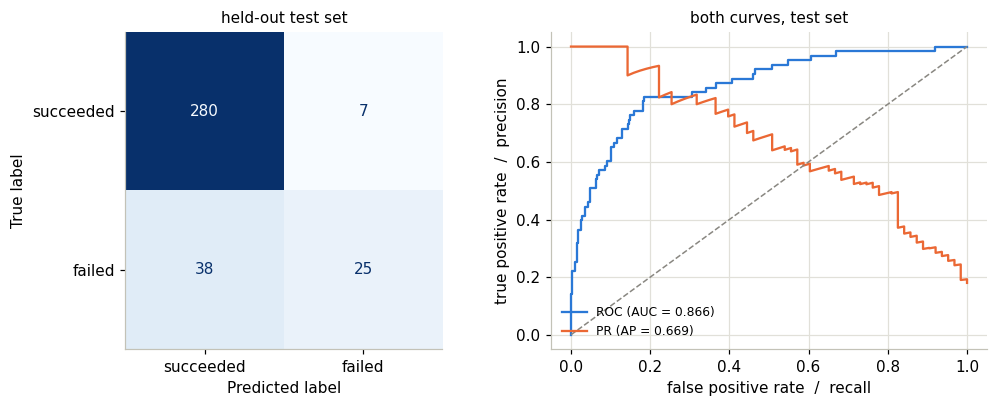

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test),
                       display_labels=["succeeded", "failed"]).plot(
    ax=ax[0], cmap="Blues", colorbar=False, values_format="d")
ax[0].set_title("held-out test set", fontsize=10)
ax[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, y_score_test)
pr, rc, _ = precision_recall_curve(y_test, y_score_test)
ax[1].plot(fpr, tpr, color=BLUE,
           label=f"ROC (AUC = {roc_auc_score(y_test, y_score_test):.3f})")
ax[1].plot(rc, pr, color=ORANGE,
           label=f"PR (AP = {average_precision_score(y_test, y_score_test):.3f})")
ax[1].plot([0, 1], [0, 1], ls="--", color=MUTED, lw=1)
ax[1].set_xlabel("false positive rate  /  recall")
ax[1].set_ylabel("true positive rate  /  precision")
ax[1].legend(loc="lower left", fontsize=8)
ax[1].set_title("both curves, test set", fontsize=10)
plt.tight_layout()
plt.show()

### 10.1 The protocol, in one picture

```
all logged picks
      |
      +--> hold out a TEST set  (stratified, locked away)
      |
      +--> TRAINING set
              |
              +--> k-fold CV  ---> learning curves      (is it data or the model?)
              |                --> validation curves    (which way does this knob go?)
              |                --> grid / random search (pick the hyperparameters)
              |                --> precision / recall   (what kind of mistakes?)
              |
              +--> refit the winner on the whole training set
                        |
                        v
                 score ONCE on the test set   <-- the number you report
```

**The rules that make the number trustworthy**

1. The test set is opened exactly once, at the end.
2. Every fitted preprocessing step lives inside the `Pipeline`.
3. Classification folds are stratified.
4. Report mean ± std across folds, not a single number.
5. Choose the metric from the cost of the mistakes, not from habit.
6. If samples are grouped (same part, same shift, same robot), split by group —
   see `GroupKFold`. Random splits leak between near-duplicate rows.

---
## 11. Exercises

1. **Fold count.** Re-run the §3.1 cross-validation with $k = 3, 5, 10, 20$. Plot the mean
   validation AUC and its standard deviation against $k$. What happens to the estimate, its
   spread, and the run time?

2. **Leakage, measured.** Fit a `StandardScaler` on all of `X_train` first, then cross-validate
   a bare `SVC` on the scaled array. Compare with the pipeline version. How large is the
   optimistic bias here, and why is it small in this particular case? Repeat with
   `SelectKBest(k=3)` in place of the scaler and see the bias grow.

3. **A different model family.** Replace the SVM with `RandomForestClassifier` and tune
   `n_estimators`, `max_depth` and `min_samples_leaf` with `RandomizedSearchCV` (`n_iter=30`).
   Does it beat the tuned SVM on ROC AUC? On average precision? Does it need the scaler?

4. **Budget experiment.** Run `RandomizedSearchCV` with `n_iter` = 5, 10, 20, 40, 80, each with
   10 different `random_state` values. Plot the mean and spread of `best_score_` against the
   budget. At what budget do the returns flatten out?

5. **Choose an operating point.** Assume a missed failure (FN) costs 12 units and a false alarm
   (FP) costs 1 unit. Sweep the decision threshold over `decision_function` outputs, compute the
   total cost on cross-validated predictions, and find the threshold that minimises it. How far
   is it from the default 0, and what precision/recall does it give?

6. **Imbalance.** Re-run the grid search with `SVC(class_weight="balanced")`. Which metrics
   improve, which get worse, and does ROC AUC move at all? Explain the pattern in terms of what
   `class_weight` actually changes.

7. **Grouped data.** Suppose the 1400 picks come from only 40 distinct part types, and rows from
   the same part type are highly similar. Add a synthetic `part_id` column, then compare
   `StratifiedKFold` with `StratifiedGroupKFold(groups=part_id)`. Which gives the lower score,
   and which one is telling the truth about a *new* part type?

8. **Feature engineering vs. tuning.** Add two physics features — `required_force / grip_force`
   and `mass × grasp_offset` — and re-fit the *linear* baseline. How much of the gap between the
   linear model and the tuned SVM does feature engineering close on its own?

---
## References and further reading

- scikit-learn User Guide, **§3 Model selection and evaluation** —
  <https://scikit-learn.org/stable/model_selection.html> (cross-validation, tuning, metrics)
- scikit-learn, *Validation curves: plotting scores to evaluate models* —
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- J. Bergstra & Y. Bengio, "Random Search for Hyper-Parameter Optimization",
  *JMLR* 13 (2012) 281–305 — the paper behind §7.
- T. Fawcett, "An Introduction to ROC Analysis", *Pattern Recognition Letters* 27 (2006) 861–874.
- T. Saito & M. Rehmsmeier, "The Precision-Recall Plot Is More Informative than the ROC Plot
  When Evaluating Binary Classifiers on Imbalanced Datasets", *PLoS ONE* 10(3) (2015).
- G. Varoquaux, "Cross-validation failure: small sample sizes lead to large error bars",
  *NeuroImage* 180 (2018) 68–77 — on how noisy CV estimates really are.
- A. Géron, *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow*, 3rd ed.,
  O'Reilly 2022, Ch. 2–3.
- For the grasping side: J. Mahler et al., "Dex-Net 2.0: Deep Learning to Plan Robust Grasps
  with Synthetic Point Clouds and Analytic Grasp Metrics", *RSS* 2017.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>